# UMAP

### Faster than t-SNE, and it keeps more of the shape, but check that yourself

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What UMAP optimises and how that differs from t-SNE, what `n_neighbors` and `min_dist` actually change, how to measure the "preserves global structure" claim instead of repeating it, and why having a `transform` changes where you are allowed to use it |
| **You should already know** | [t-SNE](../03-t-sne/), [PCA](../01-principal-component-analysis/) |
| **Datasets** | UCI Dry Bean, UCI Breast Cancer |
| **Runtime** | Two to four minutes on a laptop CPU |
| **Next** | [06-05 Filter, wrapper, and embedded methods](../05-feature-selection/) |

---

## 1. The idea

[t-SNE](../03-t-sne/) turned distances into probabilities and then shuffled points
around in two dimensions until the low-dimensional probabilities matched the
high-dimensional ones. UMAP starts from a different place and ends up somewhere
that looks similar, so it is worth being precise about the difference.

UMAP builds a **graph** first.

1. For each point, find its `n_neighbors` nearest neighbours. Measure how far away
   they are *relative to the closest one*, so every point gets its own local ruler.
   A point in a sparse region and a point in a dense region both end up with
   neighbours at "distance about 1" on their own scale.
2. Turn those rescaled distances into edge weights between 0 and 1. Read a weight
   as a confidence: how sure am I that these two points are connected.
3. Point A's confidence about B and B's confidence about A disagree. Combine them
   into one number per edge. This is the step the paper describes with fuzzy
   simplicial sets; in code it is a symmetrisation of a sparse weight matrix.
4. Drop the points into two dimensions and build the same kind of weighted graph
   there. Then minimise the **cross-entropy** between the two sets of edge weights:
   connected pairs are pulled together, randomly sampled pairs are pushed apart.

Both methods are about neighbours. The difference that matters is the
normalisation. t-SNE's probabilities are normalised over *all* pairs, so every pair
is coupled to every other pair, which makes it slow and makes the layout obsess
over local detail. UMAP's edge weights are independent of each other, and the
repulsion is applied by sampling random pairs rather than by a global sum. That
repulsion keeps working at long range, and it is the mechanism behind the claim
that UMAP holds on to more of the coarse arrangement.

Two things follow from the graph construction. UMAP is faster, because it never
forms the full pair-wise matrix. And once the graph and the layout exist, a new
point can be attached to the existing graph and placed, which is why UMAP has a
`transform` method and t-SNE does not. Section 4 is about that.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### If you do not have umap-learn installed

UMAP is not part of scikit-learn. It lives in a separate package:

```
pip install umap-learn
```

I did not want this notebook to be unreadable for anyone who has not installed it,
and I did not want the book's CI to fall over on a missing dependency. So the cell
below tries the import, and if it fails it substitutes two scikit-learn manifold
methods that make the same argument:

| | |
|---|---|
| [`Isomap`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html) | Neighbour graph, then geodesic distances along that graph, then classical MDS on them. It is explicitly a global-structure method, and it has a `transform` |
| [`SpectralEmbedding`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.SpectralEmbedding.html) | Neighbour graph, then the leading eigenvectors of its Laplacian. This is the same family of ideas UMAP uses to *initialise* its layout |

Every figure and every number below is produced either way, and every cell prints
the name of the method it actually used. What you lose without `umap-learn` is the
`min_dist` dial, which has no scikit-learn equivalent, so that part of section 2
shows one dial instead of two.

Read the substitution as a substitution, not as a stand-in. Isomap is a different
algorithm with a different objective, and section 5 is where that stops being a
detail: the rigged three-cluster test comes out one way under Isomap and the other
way under UMAP, and that section explains why. Wherever a conclusion depends on
which package was installed, I say so instead of letting the printout speak for a
method that never ran.

In [2]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, SpectralEmbedding, TSNE, trustworthiness

try:
    from umap import UMAP
    HAVE_UMAP = True
except ImportError:
    # The ordinary case: the package is simply not installed.
    HAVE_UMAP = False
except Exception as problem:
    # The annoying case: it is installed but numba and llvmlite disagree with the
    # current numpy. Treat it as missing rather than killing the notebook.
    HAVE_UMAP = False
    print(f"umap-learn is present but would not import ({type(problem).__name__}).")

REDUCER = "UMAP" if HAVE_UMAP else "Isomap"

print(f"umap-learn available : {HAVE_UMAP}")
print(f"neighbour method used: {REDUCER}")
if not HAVE_UMAP:
    print("running the scikit-learn fallback - pip install umap-learn for the real thing")


def neighbour_embed(data, n_neighbors=15, min_dist=0.1, seed=SEED, n_epochs=None):
    """Two dimensions from UMAP, or from Isomap when umap-learn is missing.

    min_dist is ignored by the fallback because scikit-learn has nothing like it.
    The retry loop exists because Isomap needs a connected neighbour graph and a
    small k on a small subsample does not always give one.
    """
    if HAVE_UMAP:
        return UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist,
                    random_state=seed, n_epochs=n_epochs).fit_transform(data)

    ceiling = len(data) - 1
    for k in [min(n_neighbors, ceiling), min(n_neighbors * 3, ceiling), min(60, ceiling)]:
        try:
            return Isomap(n_components=2, n_neighbors=k).fit_transform(data)
        except Exception:
            continue
    print("Isomap could not embed this subset; this panel falls back to PCA.")
    return PCA(n_components=2, random_state=SEED).fit_transform(data)


def make_reducer():
    """A fresh, unfitted two-dimensional reducer that has a transform method."""
    if HAVE_UMAP:
        return UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
    return Isomap(n_components=2, n_neighbors=15)


def paint(ax, points, labels, groups, size=5, alpha=0.55):
    """Scatter an embedding coloured by group, with the axes stripped."""
    for i, group in enumerate(groups):
        sel = labels == group
        ax.scatter(points[sel, 0], points[sel, 1], s=size, alpha=alpha,
                   c=style.PALETTE[i % len(style.PALETTE)], linewidths=0, label=str(group))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

umap-learn available : False
neighbour method used: Isomap
running the scikit-learn fallback - pip install umap-learn for the real thing


In [3]:
from sklearn.preprocessing import StandardScaler

X, y = datasets.dry_bean()
rng = np.random.default_rng(SEED)
subset = rng.choice(len(X), 3000, replace=False)
X_small = StandardScaler().fit_transform(X.values[subset])
y_small = y.values[subset]
varieties = sorted(set(y_small))
print(f"{len(X_small):,} beans sampled from {len(X):,}, {X_small.shape[1]} features")

3,000 beans sampled from 13,611, 16 features


### The same beans, three ways

PCA       0.0 s
t-SNE    11.3 s
Isomap    2.1 s


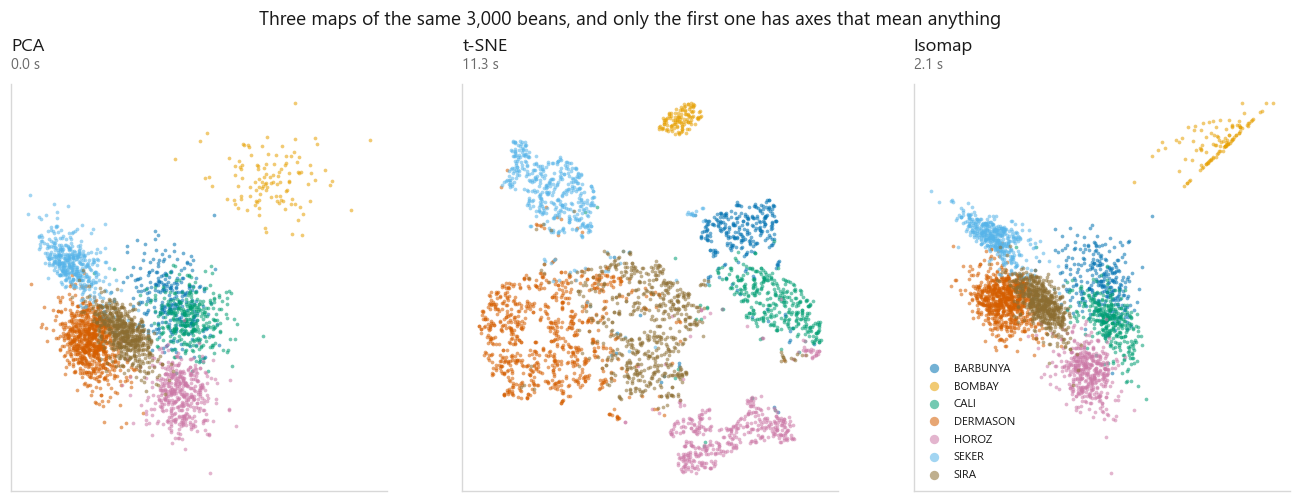

In [4]:
start = time.perf_counter()
pca_points = PCA(n_components=2, random_state=SEED).fit_transform(X_small)
pca_seconds = time.perf_counter() - start

start = time.perf_counter()
tsne_points = TSNE(n_components=2, perplexity=30, random_state=SEED,
                   init="pca").fit_transform(X_small)
tsne_seconds = time.perf_counter() - start

start = time.perf_counter()
nb_points = neighbour_embed(X_small, n_neighbors=15, min_dist=0.1)
nb_seconds = time.perf_counter() - start

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8))
panels = [(pca_points, "PCA", pca_seconds),
          (tsne_points, "t-SNE", tsne_seconds),
          (nb_points, REDUCER, nb_seconds)]
for ax, (points, name, seconds) in zip(axes, panels):
    paint(ax, points, y_small, varieties, size=6, alpha=0.55)
    style.title(ax, name, f"{seconds:.1f} s")
axes[2].legend(fontsize=7.5, markerscale=2.5, loc="best")
fig.suptitle("Three maps of the same 3,000 beans, and only the first one has axes that mean anything",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-three-maps.png")

print(f"PCA    {pca_seconds:6.1f} s")
print(f"t-SNE  {tsne_seconds:6.1f} s")
print(f"{REDUCER:<6} {nb_seconds:6.1f} s")

Compare the timings printed above rather than trusting a blog post, but read the
label on the third one first. Without `umap-learn` that panel is Isomap, which has
its own cost profile: a neighbour graph, then shortest paths through it, then an
eigendecomposition. Whatever it prints is not evidence about UMAP's speed in
either direction.

The UMAP speed claim is a claim about scale anyway, not about three thousand rows.
t-SNE normalises over all pairs, so every pair is coupled to every other one, and
that is the part which starts to hurt at tens of thousands of rows. At this size
everything here finishes while you are still reading the cell.

## 2. The two dials

`n_neighbors` is the one that matters. It sets how many neighbours define "local"
when the graph is built, and it is the closest thing UMAP has to t-SNE's
`perplexity`:

- **Small** (2 to 10): the graph only connects very close points, so the layout
  splinters into many small islands and shows fine detail. Whether that detail is
  real is a separate question.
- **Large** (50 to 200): the graph reaches further, each point's neighbourhood
  overlaps many others, and the layout is forced to respect a broader arrangement.
  Fine structure gets smoothed away.

This is the local-versus-global dial, and there is no correct setting. There is
only the scale you are asking about.

`min_dist` is the packing dial, and it does something narrower than people assume.
It does **not** touch the graph. It sets a floor on how close two points are
allowed to sit in the output layout:

- **Small** (0.0 to 0.1): points clump into tight balls. Good when you want to see
  whether clusters exist at all.
- **Large** (0.5 to 0.99): points spread out evenly. Good when you want to see the
  shape of a group rather than count groups.

Changing `min_dist` changes how a plot looks without changing what the algorithm
concluded about the data. That is worth knowing before you tune it until the
picture agrees with you.

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


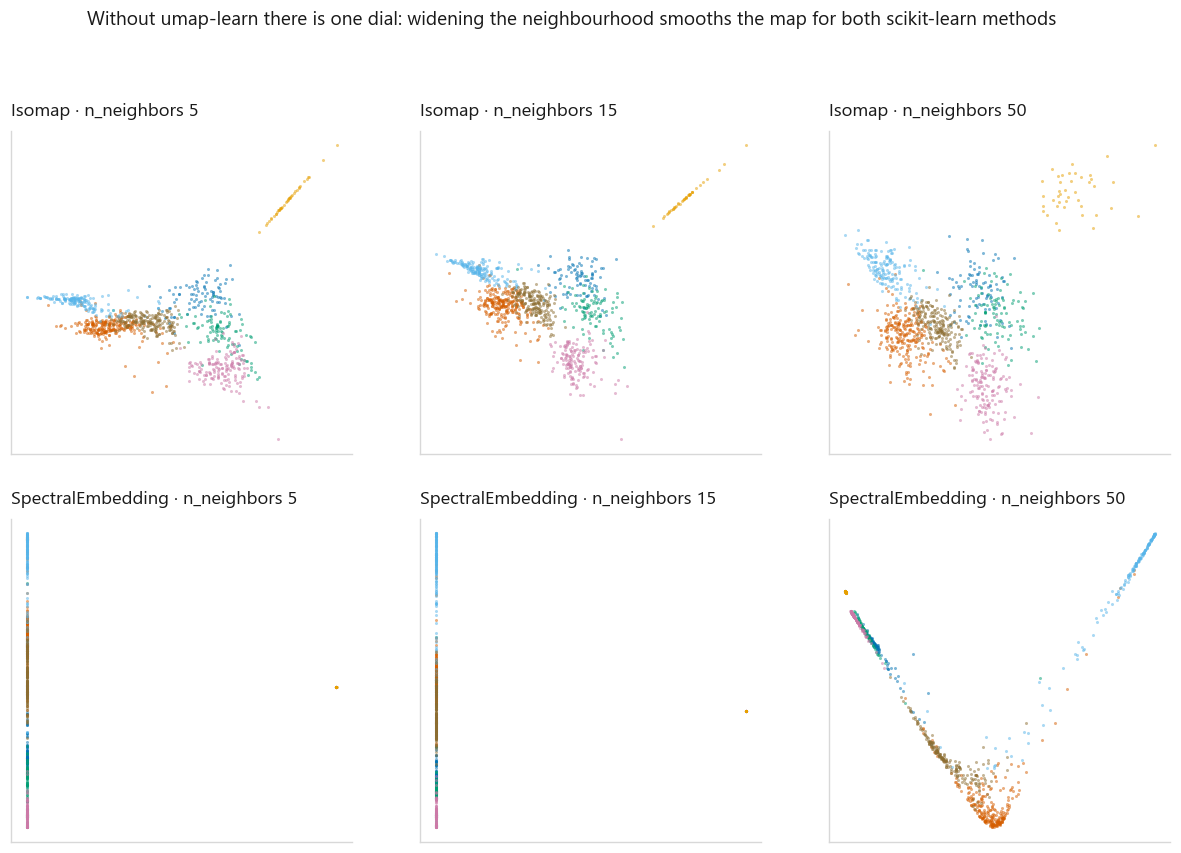

In [5]:
X_grid = X_small[:1000]
y_grid = y_small[:1000]
neighbour_values = [5, 15, 50]
dist_values = [0.0, 0.25, 0.8]

if HAVE_UMAP:
    fig, axes = plt.subplots(3, 3, figsize=(12.0, 11.4))
    for r, n_neighbors in enumerate(neighbour_values):
        for c, min_dist in enumerate(dist_values):
            # n_epochs is capped so nine fits stay inside the runtime budget.
            points = neighbour_embed(X_grid, n_neighbors=n_neighbors,
                                     min_dist=min_dist, n_epochs=200)
            paint(axes[r, c], points, y_grid, varieties, size=4, alpha=0.5)
            style.title(axes[r, c], f"n_neighbors {n_neighbors} · min_dist {min_dist}")
    headline = ("Down the rows the map trades detail for arrangement; "
                "across the columns nothing changes except how tightly it packs")
else:
    fig, axes = plt.subplots(2, 3, figsize=(13.6, 8.4))
    for c, n_neighbors in enumerate(neighbour_values):
        paint(axes[0, c], neighbour_embed(X_grid, n_neighbors=n_neighbors),
              y_grid, varieties, size=4, alpha=0.5)
        style.title(axes[0, c], f"Isomap · n_neighbors {n_neighbors}")

        spectral = SpectralEmbedding(n_components=2, n_neighbors=n_neighbors,
                                     random_state=SEED).fit_transform(X_grid)
        paint(axes[1, c], spectral, y_grid, varieties, size=4, alpha=0.5)
        style.title(axes[1, c], f"SpectralEmbedding · n_neighbors {n_neighbors}")
    headline = ("Without umap-learn there is one dial: widening the neighbourhood "
                "smooths the map for both scikit-learn methods")

fig.suptitle(headline, x=0.5, y=1.01, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-dials.png")

Which axis of that grid is which depends on what was installed. With `umap-learn`
the rows are `n_neighbors` and the columns are `min_dist`; without it the columns
are `n_neighbors` and the two rows are two different scikit-learn methods. The
figure's own heading says which one you are looking at.

Either way, follow `n_neighbors`. Widening the neighbourhood merges things that a
narrow neighbourhood kept apart, and the number of visible groups changes with it.
A reader shown only one panel would count a different number of clusters depending
on which panel you picked. `min_dist`, when the grid has it at all, changes the
packing and nothing else.

**Try three settings of `n_neighbors` before you believe any of them.** It is the
same rule as perplexity in [the t-SNE notebook](../03-t-sne/), for the same reason.

## 3. Does it really preserve global structure?

This is the claim that sells UMAP, and it is repeated far more often than it is
checked. It is easy to check.

Take every pair of points. Measure the distance between them in the original
feature space, and the distance between them in the two-dimensional map. If the
map kept the coarse arrangement, those two sets of distances should rank in
roughly the same order, so their rank correlation will be high. If the map only
kept neighbourhoods, near pairs will still be near but far pairs will be scattered
arbitrarily, and the correlation will drop.

I use Spearman rather than Pearson because no method here promises to preserve
distances on a linear scale, only their ordering.

Against that I put **trustworthiness**, which scikit-learn provides directly. It
asks the opposite question: of the points that are neighbours in the map, how many
were neighbours in the original space? That is a purely local score. A method can
score well on one and badly on the other, and seeing both is the point.

In [6]:
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

X_corr = X_small[:1000]
y_corr = y_small[:1000]
d_high = pdist(X_corr)

maps = {
    "PCA": PCA(n_components=2, random_state=SEED).fit_transform(X_corr),
    "t-SNE": TSNE(n_components=2, perplexity=30, random_state=SEED,
                  init="pca").fit_transform(X_corr),
    REDUCER: neighbour_embed(X_corr, n_neighbors=15, min_dist=0.1),
}

scores = {}
for name, points in maps.items():
    d_low = pdist(points)
    scores[name] = {
        "global (distance rank corr)": float(spearmanr(d_high, d_low).statistic),
        "local (trustworthiness k=15)": float(trustworthiness(X_corr, points, n_neighbors=15)),
    }

table = pd.DataFrame(scores).T
print(table.round(4).to_string())

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


        global (distance rank corr)  local (trustworthiness k=15)
PCA                          0.9524                        0.9434
t-SNE                        0.8516                        0.9875
Isomap                       0.9499                        0.9445


PCA      global 0.952   local 0.943
t-SNE    global 0.852   local 0.988
Isomap   global 0.950   local 0.944

gaps between the three, on each column
  global PCA     minus Isomap  +0.0025
  global PCA     minus t-SNE   +0.1007
  global Isomap  minus t-SNE   +0.0982
  local  PCA     minus Isomap  -0.0011
  local  PCA     minus t-SNE   -0.0441
  local  Isomap  minus t-SNE   -0.0430


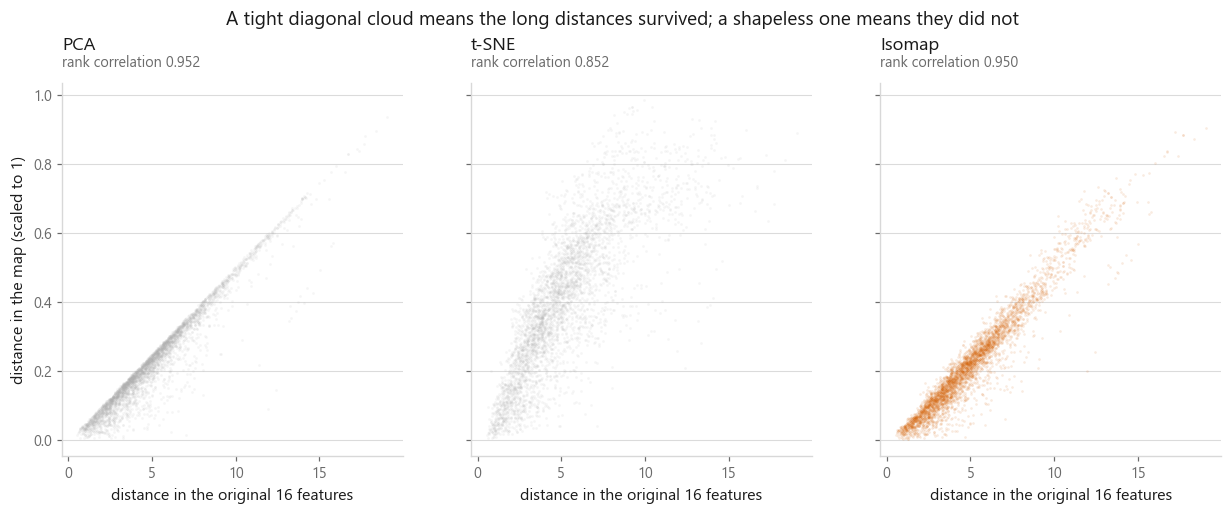

In [7]:
pair_sample = rng.choice(len(d_high), 4000, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.4), sharex=True, sharey=True)
for ax, (name, points) in zip(axes, maps.items()):
    d_low = pdist(points)
    colour = style.HIGHLIGHT if name == REDUCER else style.NEUTRAL
    ax.scatter(d_high[pair_sample], d_low[pair_sample] / d_low.max(),
               s=3, alpha=0.12, c=colour, linewidths=0)
    style.title(ax, name, f"rank correlation {scores[name]['global (distance rank corr)']:.3f}")
    ax.set_xlabel("distance in the original 16 features")
axes[0].set_ylabel("distance in the map (scaled to 1)")
fig.suptitle("A tight diagonal cloud means the long distances survived; a shapeless one means they did not",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-global-structure.png")

for name, row in scores.items():
    print(f"{name:<8} global {row['global (distance rank corr)']:.3f}   "
          f"local {row['local (trustworthiness k=15)']:.3f}")

# Which pairs actually separate? A gap of a couple of thousandths on these
# indices is not a ranking, so print the gaps rather than leaving the reader to
# eyeball a table and invent an ordering.
print("\ngaps between the three, on each column")
for column in table.columns:
    values = table[column]
    for a, b in [("PCA", REDUCER), ("PCA", "t-SNE"), (REDUCER, "t-SNE")]:
        print(f"  {column[:6]:<6} {a:<7} minus {b:<7} "
              f"{values[a] - values[b]:+.4f}")

PCA is the reference for the global column: it is a linear projection, so long
distances can only shrink, never get reshuffled. t-SNE is the reference for the
local column, since neighbourhoods are the only thing it sets out to keep.

The printed gaps are what to read, and on this data they say something more
useful than a ranking would. **Only one of the three methods is doing something
different.** t-SNE gives up a large amount of the global column to buy a large
amount of the local one, and both of those movements are far too big to be
noise. The other two land within a few thousandths of each other on both
columns, and a few thousandths of a rank correlation over a thousand points is
not a difference I would report, let alone rank.

So the trade-off this section exists to show is real, and it has exactly one
method on the far side of it. That is worth knowing before you go shopping for a
non-linear reducer: whether you get a genuinely different picture depends on
whether the objective gives up distances, and not every neighbour-graph method
does. Note also which row label the fallback printed, because a method that
minimises error on distances has no reason to lose the global column at all.

Two caveats that matter more than the numbers themselves.

First, this is **one dataset at one setting**. `n_neighbors` moves the global score
directly (that is what the dial does), so a comparison at `n_neighbors=15` against
`perplexity=30` is one point on two different curves. If global structure is what
you need, run this test on your own data at the settings you plan to use.

Second, a strong global score means different things for different methods. Isomap
minimises error on distances, so scoring well in that column is what it was built
to do rather than something it discovered. UMAP's version of the claim is the
weaker one: more global structure *than t-SNE*, which keeps almost none. That is a
low bar, and clearing it does not turn a UMAP layout into a distance-preserving
projection. If you need distances, use a method whose objective is distances: PCA,
or the geodesic-MDS route that section 5 comes back to.

## 4. It has a transform, so it can go in a pipeline

This is the practical difference, and it is bigger than the speed.

t-SNE has no `transform`. Its embedding is an optimisation over one fixed set of
points, so a new point cannot be placed without refitting everything. UMAP keeps
the fitted graph, so a new point can be attached to it and laid out against the
existing coordinates. Isomap does the same thing by a different route.

In [8]:
candidates = [
    ("PCA", PCA(n_components=2)),
    ("t-SNE", TSNE(n_components=2)),
    ("SpectralEmbedding", SpectralEmbedding(n_components=2)),
    (REDUCER, make_reducer()),
]
print("has a .transform method?")
for name, estimator in candidates:
    print(f"  {name:<20} {hasattr(estimator, 'transform')}")

has a .transform method?
  PCA                  True
  t-SNE                False
  SpectralEmbedding    False
  Isomap               True


The consequence: fit the reducer on the training half only, then `transform` the
held-out half. The test rows never influence the map, so there is no leakage.

training rows : 398
held-out rows : 171
held-out rows whose nearest training neighbour in the map shares their class: 90.6%


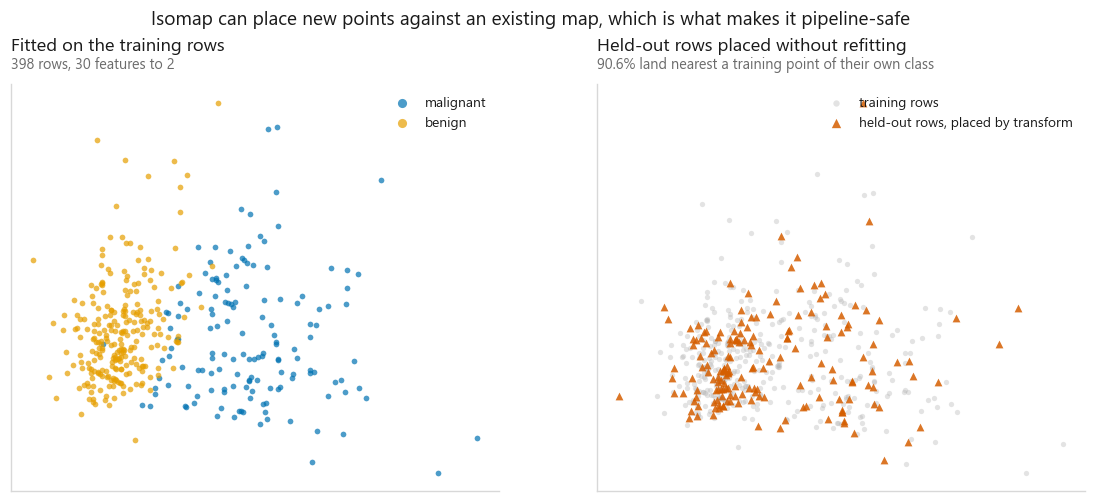

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

X_bc, y_bc = datasets.breast_cancer()
class_names = {0: "malignant", 1: "benign"}

X_tr, X_te, y_tr, y_te = train_test_split(
    X_bc.values, y_bc.values, test_size=0.3, stratify=y_bc.values, random_state=SEED)

scaler = StandardScaler().fit(X_tr)          # fitted on train only, like the reducer
reducer = make_reducer()
train_points = reducer.fit_transform(scaler.transform(X_tr))
test_points = reducer.transform(scaler.transform(X_te))

# Did the held-out points land near the right neighbourhood? Ask the nearest
# training point in the map what class it is.
finder = NearestNeighbors(n_neighbors=1).fit(train_points)
_, nearest = finder.kneighbors(test_points)
agreement = float((y_tr[nearest[:, 0]] == y_te).mean())

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))

for i, label in enumerate(sorted(class_names)):
    sel = y_tr == label
    axes[0].scatter(train_points[sel, 0], train_points[sel, 1], s=14, alpha=0.7,
                    c=style.PALETTE[i], linewidths=0, label=class_names[label])
axes[0].legend(fontsize=9, markerscale=1.6)
style.title(axes[0], "Fitted on the training rows", f"{len(X_tr)} rows, 30 features to 2")

axes[1].scatter(train_points[:, 0], train_points[:, 1], s=12, alpha=0.35,
                c=style.NEUTRAL, linewidths=0, label="training rows")
axes[1].scatter(test_points[:, 0], test_points[:, 1], s=26, alpha=0.85,
                c=style.HIGHLIGHT, marker=style.MARKERS[2], linewidths=0,
                label="held-out rows, placed by transform")
axes[1].legend(fontsize=9, markerscale=1.2)
style.title(axes[1], "Held-out rows placed without refitting",
            f"{agreement:.1%} land nearest a training point of their own class")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
fig.suptitle(f"{REDUCER} can place new points against an existing map, which is what makes it pipeline-safe",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-transform.png")

print(f"training rows : {len(X_tr)}")
print(f"held-out rows : {len(X_te)}")
print(f"held-out rows whose nearest training neighbour in the map shares their class: {agreement:.1%}")

Being *allowed* in a pipeline is not the same as *helping* in one. Squeezing 30
features into 2 throws away a lot, and whether that is a good trade is a question
with a number attached.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)
pipelines = {
    "all 30 features": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000)),
    "PCA to 2D": make_pipeline(
        StandardScaler(), PCA(n_components=2, random_state=SEED),
        LogisticRegression(max_iter=5000)),
    f"{REDUCER} to 2D": make_pipeline(
        StandardScaler(), make_reducer(), LogisticRegression(max_iter=5000)),
}

results = {}
for name, pipeline in pipelines.items():
    start = time.perf_counter()
    fold_scores = cross_val_score(pipeline, X_bc.values, y_bc.values, cv=folds)
    results[name] = (fold_scores.mean(), time.perf_counter() - start, fold_scores.std())
    print(f"{name:<18} accuracy {results[name][0]:.4f}   "
          f"fold sd {fold_scores.std():.4f}   ({results[name][1]:.1f} s for 5 folds)")

# The fold standard deviation above is the yardstick. Without it the three lines
# invite a ranking, and two of them are not far enough apart to earn one.
two_d = [results["PCA to 2D"][0], results[f"{REDUCER} to 2D"][0]]
print(f"\ntwo-dimensional versions differ by {abs(two_d[0] - two_d[1]):.4f}, "
      f"against a fold spread of around "
      f"{max(results['PCA to 2D'][2], results[f'{REDUCER} to 2D'][2]):.4f}")
print(f"both give up about "
      f"{results['all 30 features'][0] - max(two_d):.4f} against all 30 features")

all 30 features    accuracy 0.9789   fold sd 0.0142   (0.0 s for 5 folds)


PCA to 2D          accuracy 0.9578   fold sd 0.0179   (0.0 s for 5 folds)


Isomap to 2D       accuracy 0.9561   fold sd 0.0175   (0.4 s for 5 folds)

two-dimensional versions differ by 0.0017, against a fold spread of around 0.0179
both give up about 0.0211 against all 30 features


The reducer was refit inside every fold, on that fold's training rows only. That
is the whole reason `transform` matters: with t-SNE you cannot write this loop
without embedding train and test together, which lets the test rows shape the
representation before they are scored.

Two readings, and the printed fold spread decides which of them you are allowed
to make.

The one that holds: **squeezing thirty features into two costs accuracy**, and
the printed gap against the full feature set is several times the fold spread.
That is not a surprise and it is not a criticism of either reducer. Two
dimensions is a picture, and a picture is a lossy summary by construction. The
reason to look at the number anyway is that people reach for a reducer as a
preprocessing step on the assumption that it is free, and here it is not.

The one that does not hold: **which reducer is better.** The two two-dimensional
pipelines land inside the fold spread of each other, so this dataset does not
separate a linear projection from a neighbour graph when both are cut to two
components. Anyone reporting a winner from a difference that size is reporting
their fold split.

The mechanism is in the data rather than in the algorithms. Breast Cancer is
close to linearly separable in the original thirty columns, so a linear
projection already captures nearly all of the class-relevant variance, leaving
nothing for a non-linear method to recover. That is the same reason PCA and the
neighbour graph tied on both structure scores in section 3. A reducer that
unfolds curvature only wins where there is curvature to unfold, and this dataset
has very little.

## 5. Over-reading a plot, and which methods the warning is about

Everything [the t-SNE notebook](../03-t-sne/) said about over-reading a plot
applies to UMAP. Winning the global column against t-SNE does not make a layout a
measurement device. Here is the same rigged dataset: three clusters where I chose
the spreads and the gaps myself, so I know the right answer before I look.

Read the printout below with `REDUCER` in mind. Which method produced these numbers
decides what they mean, and that turns out to be the lesson of the section.

In [11]:
centres = np.array([[0.0, 0.0], [8.0, 0.0], [40.0, 0.0]])
spreads = [0.4, 3.0, 0.4]

truth_points, truth_labels = [], []
for i, (centre, spread) in enumerate(zip(centres, spreads)):
    truth_points.append(rng.normal(centre, spread, (300, 2)))
    truth_labels += [i] * 300
truth_points = np.vstack(truth_points)
truth_labels = np.array(truth_labels)

embedded = neighbour_embed(truth_points, n_neighbors=15, min_dist=0.1)


def radius(points, labels, i):
    sel = labels == i
    return float(np.sqrt(((points[sel] - points[sel].mean(axis=0)) ** 2).sum(axis=1).mean()))


def gap(points, labels, a, b):
    return float(np.linalg.norm(points[labels == a].mean(axis=0)
                                - points[labels == b].mean(axis=0)))


print("cluster radius:")
for i in range(3):
    print(f"  cluster {i}: real {radius(truth_points, truth_labels, i):6.2f}   "
          f"{REDUCER} {radius(embedded, truth_labels, i):6.2f}")

real_ratio = gap(truth_points, truth_labels, 0, 2) / gap(truth_points, truth_labels, 0, 1)
map_ratio = gap(embedded, truth_labels, 0, 2) / gap(embedded, truth_labels, 0, 1)
print("\ngap from cluster 0 to cluster 2, divided by gap from cluster 0 to cluster 1:")
print(f"  real   {real_ratio:.2f}")
print(f"  {REDUCER:<6} {map_ratio:.2f}")

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


cluster radius:
  cluster 0: real   0.56   Isomap   0.62
  cluster 1: real   4.25   Isomap   4.18
  cluster 2: real   0.59   Isomap   0.41

gap from cluster 0 to cluster 2, divided by gap from cluster 0 to cluster 1:
  real   4.99
  Isomap 5.02


In [12]:
# Same data, same settings, different seed. How much does the map move?
alt = neighbour_embed(truth_points, n_neighbors=15, min_dist=0.1, seed=7)
stability = float(spearmanr(pdist(embedded), pdist(alt)).statistic)
print(f"rank correlation between the two seeds' pairwise distances: {stability:.3f}")
if not HAVE_UMAP:
    print("(Isomap is deterministic, so this reads 1.000 by construction; UMAP would not)")

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


rank correlation between the two seeds' pairwise distances: 1.000
(Isomap is deterministic, so this reads 1.000 by construction; UMAP would not)


The construction is in the cell above: one cluster built much wider than the other
two, and one placed much further out than the other gap. The `real` rows are those
choices measured back off the generated points. The rows carrying the reducer's
name are what survived the trip down to two dimensions.

**If those rows are labelled `Isomap`, the embedding kept both quantities.** The
radii come back at roughly their planted scale instead of being flattened towards a
common size (wide cluster still wide by a large multiple, tight clusters still
tight), and the gap ratio comes back close to the planted one. That is what the run
stored in this repository shows, because `umap-learn` was not installed when it
executed. So if you came here expecting the map to wreck those quantities and it
did not: Isomap is not the method the warning is about.

That is the objective talking, not luck. Isomap builds a neighbour graph, measures
geodesic distances along it, and then runs classical MDS to find the coordinates
whose *distances* match those geodesics as closely as it can. Distance is the
quantity it is scored on, so radii and gaps are exactly what it works hardest to
keep. UMAP and t-SNE never look at a distance again once the neighbour graph
exists. They optimise a match between two sets of *neighbour relationships*
(cross-entropy over edge weights for UMAP, a divergence between two normalised
probability distributions for t-SNE), and neither objective can see scale. Stretch
a cluster, or slide it across the page, and the neighbour relationships are
unchanged, so nothing in the loss complains. That freedom is what lets those two
pull clusters apart so cleanly, and it is the same freedom that makes their cluster
sizes and their gaps meaningless.

So the warning stands. It is a warning about UMAP and t-SNE, and a table of Isomap
numbers is not the thing that demonstrates it.

**Cluster size means nothing in a UMAP plot.** The local rescaling in step 1 of
section 1 is exactly what destroys it. Every point gets its own ruler, so a sparse
cluster and a dense one both come out looking like ordinary neighbourhoods. Install
`umap-learn`, run this cell again, and watch the printed radii stop tracking the
real ones.

**Between-cluster distance is not a measurement in a UMAP plot either.** UMAP holds
on to more of the coarse arrangement than t-SNE does, which is a real difference
and a low bar. Keeping more of an ordering is not the same as reproducing a ratio.

**Empty space means nothing in a UMAP plot.** The gaps there come from the
repulsion term, not from the data.

**A UMAP layout is stochastic.** Changing the seed moves it. On the fallback the
stability line reads exactly one because Isomap has no random component at all, and
the cell prints a note saying so rather than letting the fallback take credit for
steadiness it never had to earn. Set `random_state` and say what you set it to, the
way every notebook in this book does.

The general rule outlives whichever package you have. Before reading a size or a
distance off a two-dimensional map, find out what the method was minimising. If it
was error on distances, sizes and distances are worth something. If it was
agreement on neighbour lists, they are decoration.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You want to look at high-dimensional data, and you have more rows than t-SNE will sit still for |
| **Also use it when** | You need a non-linear reduction *inside* a model. It has a `transform`, so this is legal |
| **Scaling needed** | Yes. It is distance-based |
| **Main dials** | `n_neighbors` (local versus global, try 5 / 15 / 50), `min_dist` (packing only, 0.0 to 0.99), `random_state` always |
| **Install** | `pip install umap-learn`. Not in scikit-learn. `Isomap` is the nearest thing that ships with it |
| **Read from it** | Which points are neighbours, and a rough sense of how groups are arranged |
| **Do not read** | Cluster sizes, exact between-cluster distances, or the meaning of empty space. That is a property of the objective: neighbour-matching losses are blind to scale |
| **If you ran the fallback** | The printed numbers came from Isomap, which minimises error on distances and therefore does keep sizes and gaps. Do not carry those results across to UMAP |
| **Before quoting the global claim** | Run the rank-correlation test in section 3 on your own data |
| **Next** | [Filter, wrapper, and embedded methods](../05-feature-selection/), which reduce dimensions by dropping columns instead of mixing them |

## What to remember

1. UMAP builds a weighted neighbour graph and minimises cross-entropy against a
   second graph in two dimensions. t-SNE matches two normalised probability
   distributions. The missing global normalisation is why UMAP is faster.
2. `n_neighbors` is the local-versus-global dial. `min_dist` only changes packing
   and never touches the graph.
3. "Preserves global structure" is a comparison to t-SNE, which preserves almost
   none. Measure it with distance rank correlation before you repeat it.
4. Trustworthiness and distance rank correlation measure different things. A
   method can win one and lose the other, so report both.
5. It has a `transform`, so it can be fitted on train and applied to test without
   leakage. That is the real advantage over t-SNE.
6. Being allowed in a pipeline does not mean it earns its place there. Check the
   cross-validated score against plain PCA and against no reduction at all.
7. Cluster size, exact cluster distance and empty space are artefacts in a UMAP
   plot for the same reason they are in a t-SNE plot: both optimise neighbour
   relationships, and neither loss changes when you rescale a cluster. A method
   that minimises error on distances, such as the Isomap fallback, keeps them,
   which is why the rigged test in section 5 answers differently depending on what
   is installed. Check the objective before you read the geometry.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [06-05 Filter, wrapper, and embedded methods](../05-feature-selection/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#UMAP` `#DimensionalityReduction` `#DataVisualization`
`#UnsupervisedLearning` `#Python` `#ScikitLearn` `#MLTutorial` `#Manifold`